In [1]:
###https://arxiv.org/pdf/2006.11239###

In [2]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from diffusers import UNet2DModel, DDIMScheduler, DDPMScheduler
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging
import numpy as np
from pathlib import Path
from PIL import Image
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [ ]:
class Config:
    # Path configurations
    DATA_DIR = project_root / "data/resized_data/fox"
    WEIGHTS_DIR = project_root / "weights/diffusion"
    HIST_DIR = project_root / "histories/diffusion"
    LOG_DIR = project_root / "logs"
    
    # Image parameters
    IMAGE_SIZE = 112
    CHANNELS = 3
    
    # Training parameters
    BATCH_SIZE = 22
    NUM_EPOCHS = 50
    LR = 1e-4
    T_MAX = NUM_EPOCHS  # For cosine annealing
    ETA_MIN = 1e-6  # Minimum learning rate
    NUM_TIMESTEPS = 1000
    
    # Sampling
    NUM_SAMPLES = 8
    SAMPLING_STEPS = 50
    
    # Device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Visualization
    PLOT_EVERY = 2
    
    # Random seed
    SEED = 42
    
torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(Config.SEED)

In [4]:
log_file = Config.LOG_DIR / "diffusion.v2_training.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s: %(message)s",
    handlers=[
        logging.FileHandler(log_file, mode="a"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger()


In [ ]:
class DiffusionDataset(Dataset):
    def __init__(self, root_dir):
        self.image_paths = [
            p for p in Path(root_dir).glob("*.*") 
            if p.suffix.lower() in [".jpg", ".png", ".jpeg"]
        ]
        self.transform = transforms.Compose([
            
            transforms.Resize(Config.IMAGE_SIZE),
            transforms.CenterCrop(Config.IMAGE_SIZE),
            transforms.RandomHorizontalFlip(p=0.5),

            transforms.ToTensor(),         
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) 
        ])
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img), 0  # Return dummy label

In [ ]:
def create_unet():
    return UNet2DModel(
        sample_size=Config.IMAGE_SIZE,
        in_channels=Config.CHANNELS,
        out_channels=Config.CHANNELS,
        layers_per_block=2,
        dropout=0.2,
        norm_num_groups=32,
        block_out_channels=(64, 128, 256, 512, 1024),
        down_block_types=(
            "DownBlock2D",
            "DownBlock2D",
            "AttnDownBlock2D",
            "AttnDownBlock2D",
            "AttnDownBlock2D",
        ),
        up_block_types=(
            "AttnUpBlock2D",
            "AttnUpBlock2D",
            "AttnUpBlock2D",
            "AttnUpBlock2D",
            "UpBlock2D",
        ),
    ).to(Config.device)

In [7]:
def tensor_to_image(tensor):
    """Convert model output tensor to PIL Image"""
    image = tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = (image * 0.5 + 0.5).clip(0, 1)
    return image


In [8]:
def plot_diffusion_steps(images, titles, figsize=(15, 3)):
    """Plot multiple images showing diffusion process"""
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [9]:
def visualize_forward_process(batch, scheduler):
    """Show noise addition at different timesteps using a scaled noise factor"""
    original = batch[0].cpu()
    images = [tensor_to_image(original)]
    titles = ["Original"]
    
    for t in [0.2, 0.4, 0.6, 0.8, 1.0]:
        timestep = torch.tensor(int(t * (Config.NUM_TIMESTEPS - 1)), device=original.device)
        noise = torch.randn_like(original)
        noisy_img = scheduler.add_noise(original, noise, timestep)
        images.append(tensor_to_image(noisy_img))
        titles.append(f"t={timestep.item()}")
    
    plot_diffusion_steps(images, titles)

In [10]:
def generate_samples(model, scheduler, num_images=4):
    """Generate and visualize samples from current model state"""
    model.eval()
    samples = torch.randn((num_images, 3, Config.IMAGE_SIZE, Config.IMAGE_SIZE)).to(Config.device)
    
    intermediate = [tensor_to_image(samples[0])]
    scheduler.set_timesteps(Config.SAMPLING_STEPS)
    
    with torch.no_grad():
        for i, t in enumerate(scheduler.timesteps):
            residual = model(samples, t).sample
            samples = scheduler.step(residual, t, samples).prev_sample
            
            if i % (Config.SAMPLING_STEPS // 5) == 0:
                intermediate.append(tensor_to_image(samples[0]))
    
    plot_diffusion_steps(intermediate, [f"Step {i*(Config.SAMPLING_STEPS//5)}" for i in range(len(intermediate))])
    model.train()

In [11]:
def save_diffusion_model(model, last_epoch_loss, model_name="diffusion.v2"):
    """
    Saves diffusion model weights and training history with merging capability
    
    Args:
        model: Diffusion UNet model
        last_epoch_loss: avg. loss of last epoch
        model_name: Prefix for saved files
    """
    # Ensure directories exist
    Config.WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
    Config.HIST_DIR.mkdir(parents=True, exist_ok=True)

    # Save model weights
    model_path = Config.WEIGHTS_DIR / f"{model_name}_model.pth"
    torch.save(model.state_dict(), model_path)
    
    # Handle training history
    history_path = Config.HIST_DIR / f"{model_name}_history.npz"

    
    # Merge with existing history if available
    if history_path.exists():
        old_history = np.load(history_path)
        old_train = old_history.get("train_losses", np.array([]))
        
        train_losses = np.concatenate([old_train, [last_epoch_loss]])
    else:
        train_losses = np.array([last_epoch_loss])
    
    # Save updated history
    np.savez(history_path,
             train_losses=train_losses,)
    
    logger.info(f"Saved model to: {model_path}")
    logger.info(f"Updated training history at: {history_path}")

def load_diffusion_history(history_path):
    """Load training history for diffusion model"""
    history = np.load(history_path)
    return {
        "train_losses": history["train_losses"]
    }

In [12]:
def count_parameters(model):
    """Utility function to count trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
def train_diffusion(model, dataloader, scheduler):
    optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LR)
    #lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.T_MAX, eta_min=Config.ETA_MIN)
    
    lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=3e-4,  
        total_steps=Config.NUM_EPOCHS * len(dataloader),  
        pct_start=0.1,
        anneal_strategy='cos',  
        final_div_factor=1e3,
    )
    
    scaler = torch.amp.GradScaler("cuda")
    best_loss = float('inf')
    
    train_loss_history = []

    for epoch in range(Config.NUM_EPOCHS):
        model.train()
        epoch_train_loss = 0.0

        # Create a progress bar for batches in the current epoch
        batch_bar = tqdm(dataloader, 
                         desc=f"Epoch {epoch+1}/{Config.NUM_EPOCHS} [Train]",
                         bar_format='{l_bar}{bar:20}{r_bar}{bar:-20b}')

        for batch_idx, batch in enumerate(batch_bar):
            clean_images = batch[0].to(Config.device)
            # Apply noise scaling
            noise = torch.randn_like(clean_images)
            timesteps = torch.randint(
                0, scheduler.config.num_train_timesteps,
                (clean_images.shape[0],),
                device=Config.device
            )
            noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

            optimizer.zero_grad()
            with torch.amp.autocast("cuda"):
                noise_pred = model(noisy_images, timesteps).sample
                loss = F.mse_loss(noise_pred, noise)

            scaler.scale(loss).backward() 
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  
            scaler.step(optimizer)
            scaler.update()
            lr_scheduler.step() #6. Update learning rate (OneCycleLR requires per-batch steps)

            epoch_train_loss += loss.item()

            # Update the progress bar with current metrics
            batch_bar.set_postfix({
                'Loss': f"{loss.item():.5f}",
                'LR': f"{optimizer.param_groups[0]['lr']:.3e}"
            })
            if batch_idx % 90 == 0:
                logger.info(f"LR: {optimizer.param_groups[0]['lr']:.4e}")

        avg_train_loss = epoch_train_loss / len(dataloader)
        train_loss_history.append(avg_train_loss)

        logger.info(
            f"Epoch {epoch+1:03d}/{Config.NUM_EPOCHS} | "
            f"Train Loss: {avg_train_loss:.5f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.3e}"
        )

        save_diffusion_model(model, avg_train_loss, model_name=f"diffusion")
        logger.info(f"Checkpoint saved at epoch {epoch+1}")
        
        if epoch % Config.PLOT_EVERY == 0:
            logger.info(f"Epoch {epoch+1} - Generating samples...")
            generate_samples(model, scheduler)
        
    logger.info("Training complete. Final model saved.")


In [14]:
def main(model_path = None):
    logger.info("Initializing diffusion model training...")
    
    # Create components
    dataset = DiffusionDataset(Config.DATA_DIR)
    dataloader = DataLoader(
        dataset, 
        batch_size=Config.BATCH_SIZE,
        shuffle=True,
        num_workers=20,
        pin_memory=True
    )
    
    model = create_unet()
    if model_path:
        model.load_state_dict(torch.load(model_path, map_location=Config.device))
        logger.info(f"Loaded model from {model_path}")
    
    scheduler = DDPMScheduler(
        num_train_timesteps=1000,
        beta_schedule="squaredcos_cap_v2",
        clip_sample=True,
        prediction_type="epsilon"  # Explicitly set prediction type
    )
    
    logger.info(f"Dataset contains {len(dataloader.dataset)} images")
    logger.info(f"Model architecture:\n{model}")
    logger.info(f"Model has {count_parameters(model):,} trainable parameters")
    logger.info(f"Training on {Config.device} with {Config.NUM_EPOCHS} epochs")
    
    # Visualize data samples
    for _ in range(3):
        sample_batch = next(iter(dataloader))[0][:4]
        visualize_forward_process(sample_batch, scheduler)
    
    # Start training
    train_diffusion(model, dataloader, scheduler)  # Pass scheduler

    
    # Final generation
    logger.info("Training completed. Generating final samples...")
    model.load_state_dict(torch.load(Config.WEIGHTS_DIR / "diffusion_epoch_final.pth"))
    generate_samples(model, scheduler, num_images=Config.NUM_SAMPLES)  # Pass scheduler


2025-02-24 11:46:14,063 INFO: Initializing diffusion model training...
2025-02-24 11:46:15,169 INFO: Dataset contains 6499 images
2025-02-24 11:46:15,171 INFO: Model architecture:
UNet2DModel(
  (conv_in): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=64, out_features=256, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=256, out_features=64, bias=True)
          (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3),

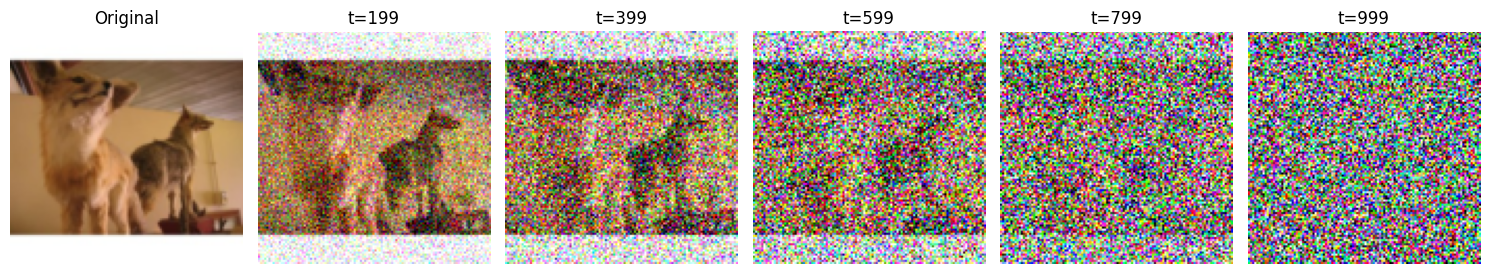

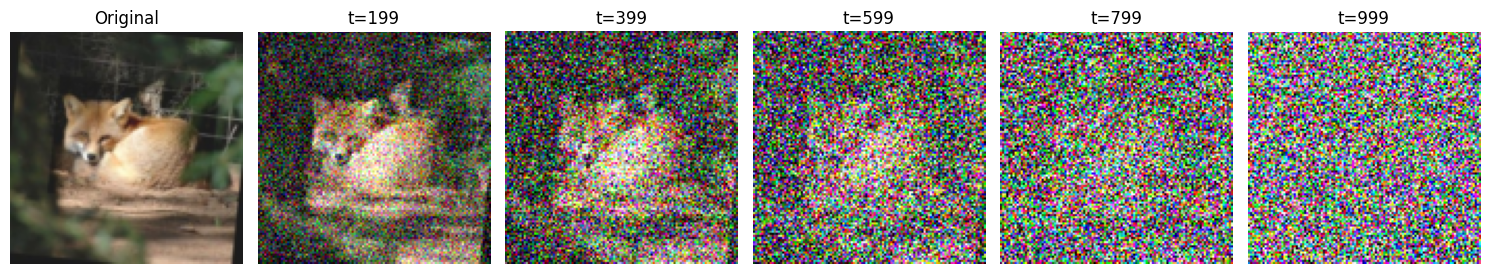

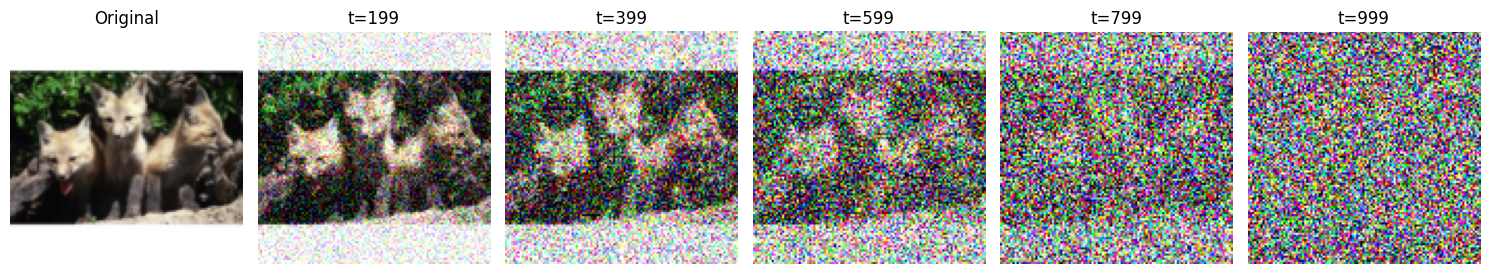

Epoch 1/200 [Train]: 100%|████████████████████| 296/296 [02:51<00:00,  1.73it/s, Loss=0.07016, LR=6.351e-05]
2025-02-24 11:49:08,373 INFO: Epoch 001/200 | Train Loss: 0.20483 | LR: 6.351e-05
2025-02-24 11:49:11,374 INFO: Saved model to: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/weights/diffusion/diffusion_model.pth
2025-02-24 11:49:11,374 INFO: Updated training history at: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/histories/diffusion/diffusion_history.npz
2025-02-24 11:49:11,374 INFO: Checkpoint saved at epoch 1
2025-02-24 11:49:11,375 INFO: Epoch 1 - Generating samples...


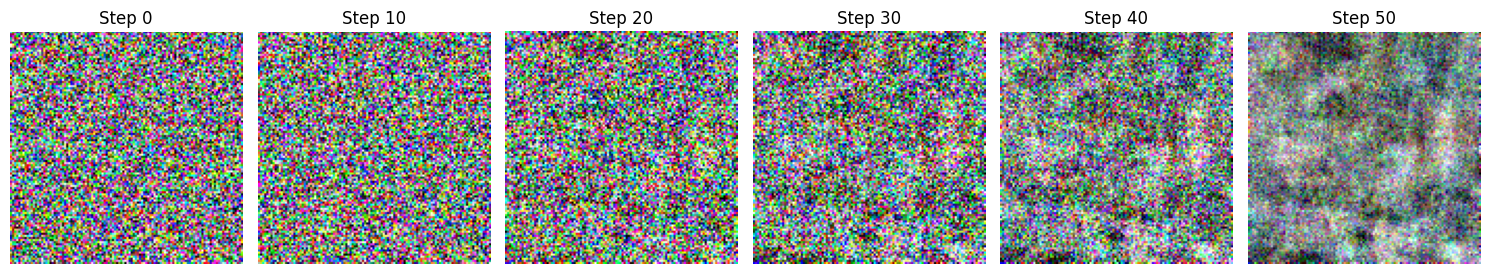

Epoch 2/200 [Train]: 100%|████████████████████| 296/296 [02:48<00:00,  1.76it/s, Loss=0.15642, LR=1.317e-04]
2025-02-24 11:52:06,521 INFO: Epoch 002/200 | Train Loss: 0.07398 | LR: 1.317e-04
2025-02-24 11:52:10,707 INFO: Saved model to: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/weights/diffusion/diffusion_model.pth
2025-02-24 11:52:10,707 INFO: Updated training history at: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/histories/diffusion/diffusion_history.npz
2025-02-24 11:52:10,708 INFO: Checkpoint saved at epoch 2
Epoch 3/200 [Train]: 100%|████████████████████| 296/296 [02:46<00:00,  1.77it/s, Loss=0.02149, LR=2.380e-04]
2025-02-24 11:54:57,606 INFO: Epoch 003/200 | Train Loss: 0.05775 | LR: 2.380e-04
2025-02-24 11:55:00,998 INFO: Saved model to: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/weights/diffusion/diffusion_model.pth
2025-02-24 11:55:00,998 INFO: Updated training history at: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/histories/diffusion/diffusio

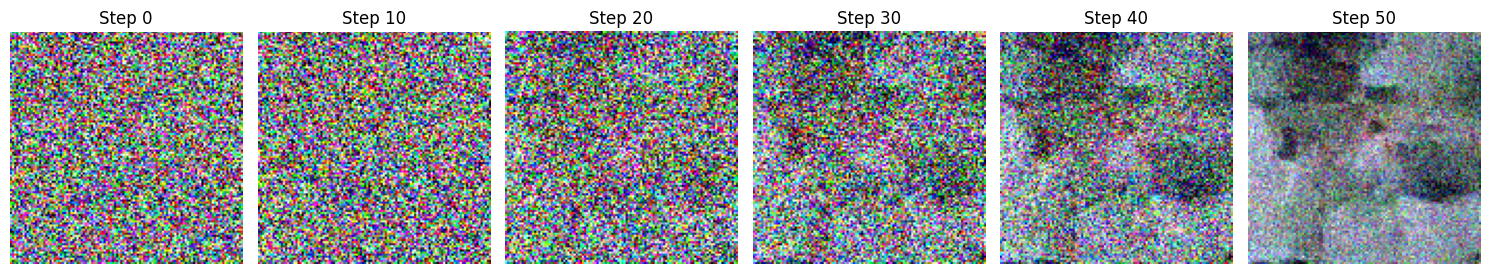

Epoch 4/200 [Train]: 100%|████████████████████| 296/296 [02:48<00:00,  1.75it/s, Loss=nan, LR=3.719e-04]    
2025-02-24 11:57:56,605 INFO: Epoch 004/200 | Train Loss: nan | LR: 3.719e-04
2025-02-24 11:57:59,899 INFO: Saved model to: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/weights/diffusion/diffusion_model.pth
2025-02-24 11:57:59,899 INFO: Updated training history at: /media/Ittwin/E/_uni/DL_Project/tiger-fox-elephant/histories/diffusion/diffusion_history.npz
2025-02-24 11:57:59,899 INFO: Checkpoint saved at epoch 4
Epoch 5/200 [Train]:  11%|██▎                 | 34/296 [00:18<02:24,  1.81it/s, Loss=nan, LR=3.884e-04]


KeyboardInterrupt: 

In [15]:
main()

In [ ]:
def plot_diffusion_history(history_path):
    """Load and plot the training history for the diffusion model."""
    history = load_diffusion_history(history_path)
    train_losses = history["train_losses"]
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label="Training Loss", marker='o')
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title("Diffusion Model Training History")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_diffusion_history(Config.HIST_DIR / "diffusion_history.v2.npz")